# Telco Customer Churn
## 1. Описание
### Цель анализа 
Бинарная классификация: **прогнозирование оттока клиентов до фактического ухода**. Практическая ценность: выявить, когда и почему клиент может уйти.

Данные взяты из датасета ["Telco Customer Churn"](https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data) на сайте kaggle. В наборе данных содержится информация о семи тысячах клиентов. Каждая строка представляет одного клиента. Клиент описывается с помощью бинарных, категориальных и числовых характеристик, которые включают информацию о самом клиенте и об услугах, которыми он пользуется.

**Целевая переменная — Churn**. Она показывает, собирается ли клиент уйти из компании. Переменная имеет два значения: Yes — клиент уходит, No — клиент остается. 

В задачах прогнозирования оттока клиентов нередко возникает дисбаланс классов из-за преобладания лояльных клиентов. Метрика accuracy неэффективна, так как высокая точность может достигаться за счёт правильного предсказания большинства, но модель плохо выявляет клиентов с высоким риском ухода. Поэтому особое внимание уделяется метрикам Recall и ROC-AUC, которые оценивают способность модели находить клиентов, склонных к оттоку, и отделять их от остальных.

Ограничения анализа: представленные данные — это статический срез. Мы не знаем, что делали клиенты после ухода: вернулись они или нет. Нет сведений о динамике изменения количества клиентов во времени.

## 2. Первичный анализ данных (EDA)
### Цели:
* Понять структуру данных;
* Выявить паттерны, связанные с оттоком;
* Найти проблемы данных, которые нужно исправлять дальше.

### 2.1 Общий обзор данных
Проверим размер датасета, наличие пропусков и дубликатов.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('В датасете ', len(df), 'строк(и) и ', len(df.columns), ' колонок(ки)')
df.sample()

В датасете  7043 строк(и) и  21  колонок(ки)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1337,6265-FRMTQ,Male,0,No,No,31,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),20.4,609.1,No


In [2]:
df.info() #какие типы данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.duplicated().sum() #проверка дубликатов

np.int64(0)

In [4]:
df.isna().sum() #проверка пропусков

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Вывод:**  
Датасет содержит 7043 наблюдения и 21 признак. Явных дубликатов строк не обнаружено, идентификатор клиента уникален. Пропущенные значения в явном виде отсутствуют, однако признак `TotalCharges` имеет тип `object`, что указывает на возможные проблемы с форматом данных и требует дополнительной проверки на этапе предобработки.

### 2.2 Анализ целевой переменной (`Churn`)

In [5]:
# расчет распределени классов
s = df['Churn'].value_counts().to_frame()
s['share_%'] = s['count'].div(s['count'].sum()).mul(100)
s

,count,share_%
Churn,,
No,5174,73.463013
Yes,1869,26.536987


**Вывод:**  
Доля клиентов, покинувших компанию (`Churn = Yes`), составляет около 26%, что указывает на умеренный дисбаланс классов. В таких условиях использование метрики accuracy может быть недостаточно информативным, поэтому при дальнейшем анализе и оценке моделей будут использоваться метрики, устойчивые к дисбалансу, такие как Recall и ROC-AUC.

### 2.3 Анализ числовых признаков.

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
len(df[df['TotalCharges'].isna()].index) #количество строк с прорусками в признаке 'TotalCharges'

11

In [7]:
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [8]:
df = df.dropna() #удаляем 11 строк с пропусками

df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


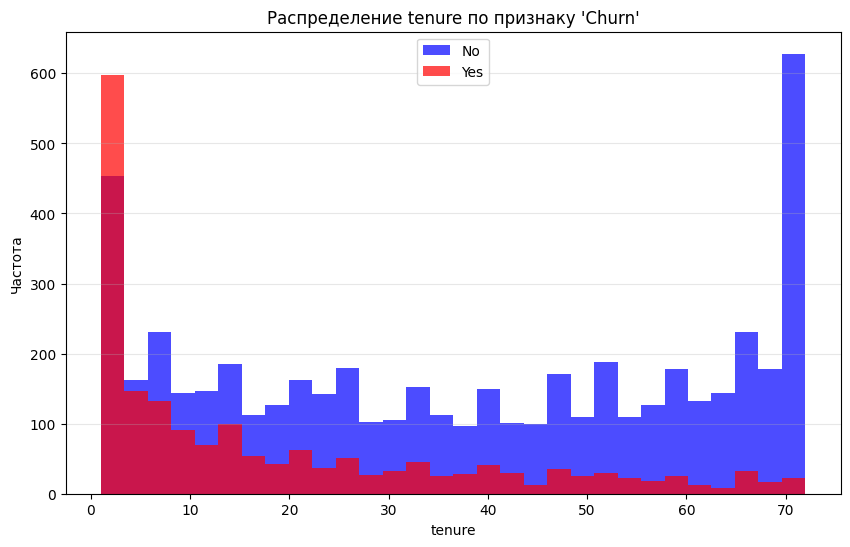

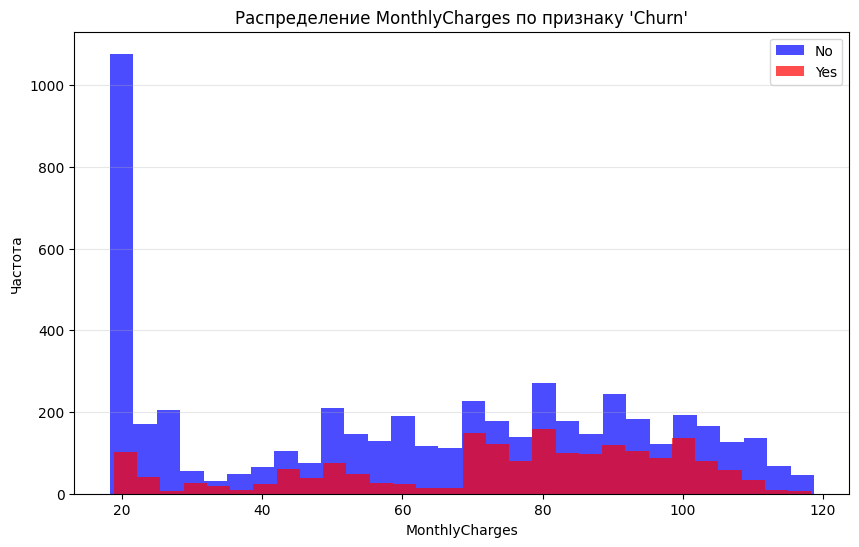

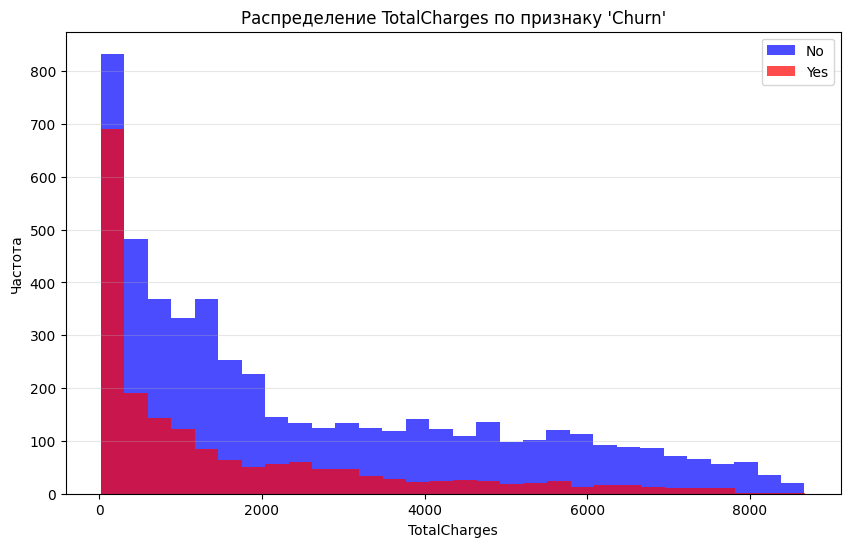

In [9]:
# функция для построения графика распределения числового признака. Данные разюиваются на две группы оставшиеся клиенты и ушедшие
def func_1(dc):
    yes = dc.loc[dc['Churn'] == 'Yes', dc.columns[1]]
    no = dc.loc[dc['Churn'] == 'No', dc.columns[1]]
    
    plt.figure(figsize=(10, 6))
    # Группа no
    plt.hist(no,
            bins=30, alpha=0.7, label='No', color='blue')
    # Группа yes
    plt.hist(yes, 
            bins=30, alpha=0.7, label='Yes', color='red')
    
    
    plt.title("Распределение " + yes.name +  " по признаку 'Churn'")
    plt.xlabel(yes.name)
    plt.ylabel('Частота')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

func_1(df[['Churn', 'tenure']])
func_1(df[['Churn', 'MonthlyCharges']])
func_1(df[['Churn', 'TotalCharges']])

**Выводы:**
1. Клиенты, покинувшие компанию, в среднем имеют значительно меньший срок обслуживания (`tenure`). Это указывает на повышенный риск оттока в первые месяцы после подключения, тогда как с увеличением срока обслуживания вероятность ухода снижается.
2. Для признака `MonthlyCharges` наблюдается различие в распределениях: клиенты с более высокими ежемесячными платежами чаще покидают компанию, что может указывать на связь между стоимостью услуг и риском оттока.
3. Признак `TotalCharges` имеет сильно скошенное распределение и тесно связан с `tenure`. Клиенты с меньшими суммарными расходами чаще относятся к группе оттока, что отражает более короткий срок их обслуживания.

### 2.4 Анализ категориальных признаков
Для оценки категориальных признаков рассчитаем вероятность оттока для каждой категории. Затем сравним эти значения с общим уровнем оттока клиентов.

In [10]:
overall_churn_rate = len(df[df['Churn'] == 'Yes']) / len(df) #базовый уровень оттока по всему датасету

#оценка уровня оттока по категориям одного признака
def churn_rate(s):
    a=pd.DataFrame()
    a['total']=(
        s.iloc[:,0]
        .value_counts()
    )
    a['churn_yes']= (
        s[s['Churn'] == 'Yes']
        .iloc[:,0]
        .value_counts()
    )
    a['churn_rate']=(
        a['churn_yes']
        .div(a['total'])
    )
    a['overall_churn_rate'] =  overall_churn_rate
    a['lift'] = a['churn_rate'] / overall_churn_rate
    a['feature'], a.index.name = a.index.name, 'category'
    a = a.reset_index()
    a = a[['feature', 'category', 'total','churn_yes','churn_rate', 'overall_churn_rate', 'lift']]

    a = a.fillna(0)
    return a

# создаем множество с названиями признаков для анализа
set_names = df.columns.to_list()
set_names = set(set_names)
set_names = set_names - {'customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'}

categories = pd.DataFrame()

#анализ каждого категориального признака
for i in set_names: 
    slicer = df.loc[:,[i, 'Churn']]
    result = churn_rate(slicer)
    categories = pd.concat([categories, result], ignore_index=True)

threshold = 50 #минимальный количество наблюдений для фильтрации шума

categories = categories[categories['total'] >= threshold] #убираем шум
categories = categories.sort_values(by='lift', ascending=False) #сортируем по lift
categories[categories['lift'] >= 1.5]

,feature,category,total,churn_yes,churn_rate,overall_churn_rate,lift
24,PaymentMethod,Electronic check,2365,1071,0.452854,0.265785,1.703836
16,Contract,Month-to-month,3875,1655,0.427097,0.265785,1.606926
8,InternetService,Fiber optic,3096,1297,0.418928,0.265785,1.576190
11,OnlineSecurity,No,3497,1461,0.417787,0.265785,1.571897
15,SeniorCitizen,1,1142,476,0.416813,0.265785,1.568232
38,TechSupport,No,3472,1446,0.416475,0.265785,1.566961
2,OnlineBackup,No,3087,1233,0.399417,0.265785,1.502782


Для каждого категориального признака был рассчитан `churn_rate` — вероятность ухода клиента при условии принадлежности к конкретной категории. В качестве базовой линии использовался общий уровень оттока по всему датасету (`overall_churn_rate`).

Для оценки относительного риска был рассчитан показатель `lift`, показывающий, во сколько раз вероятность оттока в данной категории выше или ниже среднего уровня. Категории с числом наблюдений менее 50 были исключены из анализа как статистически нестабильные.

In [11]:
strong_churn_drivers = categories[categories['lift'] >= 1.5]
strong_retention_factors = categories[categories['lift'] < 0.5]
neutral_categories = categories[ (categories['lift'] >= 0.8) & (categories['lift'] <= 1.2)]

В рамках анализа категории были разделены по степени влияния на отток. Категории с `lift` ≥ 1.5 рассматривались как сильные драйверы оттока, поскольку вероятность ухода клиентов в них как минимум в полтора раза превышает средний уровень. Категории с `lift` ≤ 0.5 интерпретировались как сильные факторы удержания. Категории с `lift` в диапазоне 0.8–1.2 считались нейтральными и не оказывающими существенного влияния на отток.

## Блок 3. Feature Engineering
Кодирование нечисловых признаков для последующего обучения модели.

### 3.1 Кадирование бинарных признаков

In [13]:
# Найти все бинарные признаки автоматически
binary_cols = df.nunique()[df.nunique() == 2].index.tolist()
for i in binary_cols:
    print('признак: ', i, ' категории: ', df[i].unique(),'\n')

признак:  gender  категории:  ['Female' 'Male'] 

признак:  SeniorCitizen  категории:  [0 1] 

признак:  Partner  категории:  ['Yes' 'No'] 

признак:  Dependents  категории:  ['No' 'Yes'] 

признак:  PhoneService  категории:  ['No' 'Yes'] 

признак:  PaperlessBilling  категории:  ['Yes' 'No'] 

признак:  Churn  категории:  ['No' 'Yes'] 



In [14]:
# Заменить бинарные значения на 0/1
for col in binary_cols:
    unique_vals = df[col].dropna().unique()
    if set(unique_vals) == {'Yes', 'No'}:
        df[col] = df[col].map({'Yes':1, 'No':0})
    elif set(unique_vals) == {'Male', 'Female'}:
        df[col] = df[col].map({'Female':1, 'Male':0})
    else:
        # на всякий случай: взять первую уникальную как 0, вторую как 1
        df[col] = df[col].map({unique_vals[0]:0, unique_vals[1]:1})

Бинарные признаки готовы к обучению.

### 3.2 Категореальнве признаки
Выбираем категории, объединяем редкие признаки в группу "Other" (менее 2% всех клиентов) и применяем One-Hot кодирование.

In [15]:
#Определяем многоклассовые признаки
all_cat_cols = df.select_dtypes(include='object').columns.tolist()
all_cat_cols.remove('customerID')
multi_class_cols = [col for col in all_cat_cols if col not in binary_cols]

total_clients = len(df)
for col in multi_class_cols:
    # Получаем все категории и их частоты из categories
    cat_counts = categories[categories['feature'] == col][['category', 'total']]
    # Список редких категорий
    rare_cats = cat_counts[cat_counts['total'] / total_clients < 0.02]['category'].tolist()
    # Заменяем редкие категории на 'Other'
    df[col] = df[col].apply(lambda x: 'Other' if x in rare_cats else x)

#One-Hot Encoding для многоклассовых признаков
df = pd.get_dummies(df, columns=multi_class_cols, drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns.tolist()
for col in bool_cols:
    df[col] = df[col].apply(lambda x: 1 if x == True else 0)

In [16]:
#One-Hot Encoding для многоклассовых признаков
df = pd.get_dummies(df, columns=multi_class_cols, drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns.tolist()
for col in bool_cols:
    df[col] = df[col].apply(lambda x: 1 if x == True else 0)

Редкие категории были объединены в группу "Other". Это позволяет снизить размерность признакового пространства и уменьшить риск переобучения.

## 4. Обучение моделей

Разделим данные на тестовую и обучающую выборки, масштабируем числовые признаки и обучим модель.

### 4.1 Обучение
`customerID` является уникальным идентификатором клиента и не несёт предиктивной информации, поэтому будет исключён из набора признаков перед обучением модели.

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Исключаем целевой признак и customerID
exclude_cols = ['customerID', 'Churn']
num_cols = df.columns.tolist()
num_cols = [col for col in num_cols if col not in exclude_cols]
X = df.drop(columns=exclude_cols)  # признаки
y = df['Churn']                 # целевая переменная

# разделяем данные на test/train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# масштабируем числовые признаки
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# обучаем модель
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Перед обучением модели числовые признаки были стандартизированы с помощью StandardScaler. 
Масштабирование выполнялось только на обучающей выборке, чтобы избежать утечки информации, 
после чего те же параметры были применены к тестовой выборке.

В качестве базовой модели была использована логистическая регрессия, позволяющая получить 
интерпретируемую baseline-оценку качества классификации.

### 4.2 Результат обучения
Сравним фактические данные с прогнозами.

In [26]:
y_pred = model.predict(X_test) 
y_proba = model.predict_proba(X_test)[:, 1] 
results = pd.DataFrame()
results['y_true'] = y_test.values # реальные дааные
results['y_pred'] = y_pred # прогноз
results['y_proba'] = y_proba # вероятность прогноза

results.sample(10)

,y_true,y_pred,y_proba
13,0,0,0.061398
702,0,0,0.046417
298,0,0,0.016634
674,0,1,0.587918
1329,0,0,0.008859
25,1,0,0.419514
75,1,1,0.586528
451,0,0,0.013970
1179,1,1,0.679888
834,0,0,0.196175


In [30]:
results['proba_bin'] = pd.qcut(results['y_proba'], q=5)

results.groupby('proba_bin')['y_true'].mean()

/tmp/ipykernel_55/160343794.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results.groupby('proba_bin')['y_true'].mean()


proba_bin
(0.00044000000000000007, 0.0275]    0.017730
(0.0275, 0.126]                     0.074733
(0.126, 0.293]                      0.224199
(0.293, 0.542]                      0.348754
(0.542, 0.847]                      0.663121
Name: y_true, dtype: float64

Клиенты были отсортированы по предсказанной вероятности оттока и разбиты на 5 равных групп. Фактическая доля ушедших клиентов монотонно возрастает от 1.8% в группе с минимальной вероятностью до 66.3% в группе с максимальной вероятностью.

Это свидетельствует о том, что модель корректно ранжирует клиентов по риску оттока и может использоваться для сегментации и приоритизации мероприятий по удержанию.

## 5. Оценка качества модели

In [32]:
from sklearn.metrics import roc_auc_score, roc_curve

# y_test — истинные метки (0 или 1)
# y_proba — вероятности принадлежности к классу 1 (выход модели)

# cчитаем AUC
auc = roc_auc_score(y_test, y_proba)
print(f"ROC‑AUC: {auc:.3f}")

# cтроим ROC‑кривую
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.show()

ROC‑AUC: 0.836


ROC-AUC модели составил 0.836, что свидетельствует о хорошем качестве ранжирования клиентов 
по риску оттока. Это означает, что в 83.6% случаев модель корректно присваивает более высокую 
вероятность ухода клиенту, который действительно ушёл, по сравнению с клиентом, который остался.

Метрика ROC-AUC выбрана из-за умеренного дисбаланса классов и ориентации задачи на 
скоринг и приоритизацию клиентов, а не на жёсткое бинарное решение.

### 5.2 Расчет порога вероятности
Порог вероятности расчитаем на основе максимизации F1-метрики, которая обеспечивает баланс между полнотой (Recall) и точностью (Precision).

In [33]:
from sklearn.metrics import precision_recall_curve, f1_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)  # +1e-10 для избежания деления на 0

# находим порог с макс. F1
optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Оптимальный порог (max F1): {optimal_threshold:.3f}")

Оптимальный порог (max F1): 0.403


Оптимальный порог составил 0.403, что означает: клиент классифицируется как склонный к уходу, если вероятность оттока по модели ≥ 40.3%.

Выбор порога ниже 0.5 является ожидаемым для задачи прогнозирования оттока в условиях дисбаланса классов и ориентации на выявление максимального числа потенциально уходящих клиентов.

In [37]:
y_pred = (y_proba >= optimal_threshold).astype(int)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[848 185]
 [118 256]]


In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1: {f1:.3f}")

Precision: 0.580
Recall: 0.684
F1: 0.628


При выбранном пороге вероятности 0.403 модель достигает Recall = 0.684, что означает выявление почти 70% клиентов, которые действительно ушли.

Precision составляет 0.580 — около 58% клиентов, помеченных моделью как склонные к уходу, действительно покинули компанию.

Такой баланс метрик является приемлемым для задачи прогнозирования оттока, где приоритетом является обнаружение максимального числа уходящих клиентов, даже ценой некоторого числа ложных срабатываний.

Ложноположительные ошибки (FP) означают дополнительные затраты на удержание клиентов, которые на самом деле не собирались уходить. Ложноотрицательные ошибки (FN) представляют более высокий риск, так как такие клиенты покидают компанию без попытки удержания.

## 6. Интерпретация модели
### 6.1 Интерпретация коэффициентов логистической регрессии

In [41]:
# Получаем коэффициенты модели
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})

# Добавим абсолютное значение для сортировки
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()

# Сортируем по влиянию
coef_df = coef_df.sort_values(by='abs_coefficient', ascending=False)

coef_df.head(15)

,feature,coefficient,abs_coefficient
4,tenure,-1.347613,1.347613
7,MonthlyCharges,-0.851551,0.851551
11,InternetService_Fiber optic,0.727745,0.727745
8,TotalCharges,0.639028,0.639028
26,Contract_Two year,-0.602591,0.602591
25,Contract_One year,-0.310898,0.310898
22,StreamingTV_Yes,0.249702,0.249702
24,StreamingMovies_Yes,0.236368,0.236368
10,MultipleLines_Yes,0.214359,0.214359
28,PaymentMethod_Electronic check,0.181473,0.181473


Коэффициенты логистической регрессии показывают направление и силу влияния признаков на вероятность оттока клиента.

Положительный коэффициент означает рост вероятности ухода клиента при увеличении значения признака, отрицательный — снижение вероятности оттока.

Для интерпретации были отсортированы признаки по абсолютному значению коэффициента, что позволяет выделить факторы с наибольшим вкладом в решение модели.

### 6.2 Интерпретация через Odds Ratio

In [42]:
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df[['feature', 'coefficient', 'odds_ratio']].head(15)

,feature,coefficient,odds_ratio
4,tenure,-1.347613,0.259860
7,MonthlyCharges,-0.851551,0.426753
11,InternetService_Fiber optic,0.727745,2.070407
8,TotalCharges,0.639028,1.894639
26,Contract_Two year,-0.602591,0.547392
25,Contract_One year,-0.310898,0.732789
22,StreamingTV_Yes,0.249702,1.283642
24,StreamingMovies_Yes,0.236368,1.266641
10,MultipleLines_Yes,0.214359,1.239068
28,PaymentMethod_Electronic check,0.181473,1.198982


Для более интуитивной интерпретации коэффициенты были преобразованы в odds ratio путём экспоненцирования.

Odds ratio показывает, во сколько раз изменяется отношение вероятности ухода к вероятности остаться при увеличении признака на одну единицу.

Значения:
- odds ratio > 1 — фактор увеличивает риск оттока
- odds ratio < 1 — фактор снижает риск оттока

### 6.3 Ключевые факторы риска оттока

Наибольший вклад в рост вероятности оттока вносят:

- краткосрочные контракты (Month-to-month)
- отсутствие технической поддержки и онлайн-безопасности
- использование оптоволоконного интернета
- электронный чек как способ оплаты
- высокая ежемесячная стоимость услуг

Факторы, снижающие вероятность оттока:

- длительный срок сотрудничества с компанией
- долгосрочные контракты (1 год и более)
- наличие дополнительных сервисов поддержки

## 7. Финальные выводы и рекомендации
### 7.1 Итоговые результаты модели
В рамках проекта была построена модель бинарной классификации для прогнозирования оттока клиентов телеком-компании.

Модель логистической регрессии показала:
- ROC-AUC: 0.836
- Recall (при оптимальном пороге): 0.684
- Precision: 0.580

Модель хорошо ранжирует клиентов по риску ухода и может быть использована в качестве скорингового инструмента.

### 7.2 Практическое применение модели
Модель может быть использована для приоритизации клиентов по риску оттока. Рекомендуемый сценарий применения:
- регулярно рассчитывать вероятность оттока для активных клиентов
- фокусировать удерживающие меры на клиентах с вероятностью ≥ 0.4
- предлагать персонализированные скидки и дополнительные сервисы
  клиентам из групп повышенного риска

### 7.3 Ограничения и возможные улучшения
Ограничения текущего решения:
- данные представляют собой статический срез без временной динамики
- отсутствует информация о поведении клиентов после ухода
- модель не учитывает историю изменений тарифов и услуг

Потенциальные улучшения:
- использование более сложных моделей (Gradient Boosting, XGBoost)
- добавление временных и поведенческих признаков
- оптимизация порога под конкретные бизнес-метрики
- A/B тестирование удерживающих стратегий